In [1]:
!pip install -q librosa soundfile

In [2]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

from IPython.display import Audio, display

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Chemistry quantum 2021-22 (distinylearn.com).gdoc', 'adhar card.pdf', 'inbound4481201554667310605.docx', 'Screenshot_2025-09-19-12-14-46-061.jpeg', '1759839573306 (1).jpg', 'Screenshot 2025-10-10 164338.png', 'Untitled video - Made with Clipchamp.mp4', 'IMG_20251030_194344 (1).jpg', 'Internship reflection video .mp4', 'MediMate - Google Chrome 2025-11-09 21-50-08.mp4', 'Colab Notebooks', 'Screenshot_2025-12-26-15-06-35-997.jpeg', 'IMG-20251228-WA0000.jpg', 'hackathon', 'WhatsApp Video 2026-01-30 at 7.31.24 PM.mp4', 'WhatsApp Video 2026-01-31 at 9.17.47 AM.mp4', 'WhatsApp Video 2026-01-31 at 9.18.01 AM (2).mp4', 'WhatsApp Video 2026-01-31 at 9.18.01 AM (1).mp4', 'anshita resume (2).pdf', '1772168638724.png', '1772081539443.pdf', 'AI_DENTAL_PROJECT_ANSHITA', 'Anshita_Singh_Resume.gdoc', '65c49a38-15d5-4949-acde-66e59205b2ab.pptx', 'final_implant_model.pt', 'Copy of final_implant_model.pt', 'Master_Dataset', 'Msk creation', 'train.cache', 'val.cache', 'Periapical_Dataset', 'Synthetix_AI

In [5]:
DATASET_PATH = "/content/drive/MyDrive/bio-cas-2024-depression-detection-grand-challenge"
print("Dataset exists:", os.path.exists(DATASET_PATH))
print(os.listdir(DATASET_PATH))

Dataset exists: True
['sample_submission.csv', 'Test.csv', 'Train.csv', 'train_json', 'train', 'test_json', 'test']


In [7]:
train_df = pd.read_csv(
    os.path.join(DATASET_PATH, "Train.csv")
)

test_df = pd.read_csv(
    os.path.join(DATASET_PATH, "Test.csv")
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (89, 7)
Test shape: (24, 5)


In [8]:
import os

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, "").count(os.sep)

    if level > 2:
        continue

    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}    {file}")

bio-cas-2024-depression-detection-grand-challenge/
    sample_submission.csv
    Test.csv
    Train.csv
    train_json/
        S011.json
        S019.json
        S014.json
        S017.json
        S003.json
        S005.json
        S033.json
        S009.json
        S016.json
        S012.json
    train/
        S008.mp3
        S007.mp3
        S002.mp3
        S011.mp3
        S004.mp3
        S009.mp3
        S005.mp3
        S003.mp3
        S026.mp3
        S017.mp3
    test_json/
        test_json/
            S103.json
            S106.json
            S086.json
            S025.json
            S095.json
            S070.json
            S010.json
            S079.json
            S093.json
            S068.json
    test/
        S006.mp3
        S025.mp3
        S048.mp3
        S039.mp3
        S013.mp3
        S041.mp3
        S018.mp3
        S010.mp3
        S038.mp3
        S001.mp3


In [9]:
display(train_df.head(10))

,Participant,File_name,Label,Score,Gender,Age,Remark
0,S026,S026.mp3,2,24,Female,23,NaN
1,S055,S055.mp3,3,37,Female,18,NaN
2,S029,S029.mp3,0,3,Female,33,NaN
3,S089,S089.mp3,0,0,Male,46,NaN
4,S005,S005.mp3,2,26,Female,16,NaN
5,S027,S027.mp3,0,2,Female,43,Bipolar
6,S051,S051.mp3,3,36,Male,21,NaN
7,S090,S090.mp3,0,0,Female,34,NaN
8,S028,S028.mp3,0,5,Female,37,NaN
9,S100,S100.mp3,0,4,Female,25,NaN


In [10]:
print("Columns:")
print(train_df.columns.tolist())

Columns:
['Participant', 'File_name', 'Label', 'Score', 'Gender', 'Age', 'Remark']


In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Participant  89 non-null     object
 1   File_name    89 non-null     object
 2   Label        89 non-null     int64 
 3   Score        89 non-null     int64 
 4   Gender       89 non-null     object
 5   Age          89 non-null     int64 
 6   Remark       6 non-null      object
dtypes: int64(3), object(4)
memory usage: 5.0+ KB


In [12]:
print("Number of participants:", train_df["Participant"].nunique())
print("Number of audio files:", train_df["File_name"].nunique())
print("Number of labels:", train_df["Label"].nunique())

Number of participants: 89
Number of audio files: 89
Number of labels: 4


In [13]:
missing = train_df.isnull().sum()

display(missing)

,0
Participant,0
File_name,0
Label,0
Score,0
Gender,0
Age,0
Remark,83


In [14]:
print(
    "Duplicate rows:",
    train_df.duplicated().sum()
)

print(
    "Duplicate participants:",
    train_df["Participant"].duplicated().sum()
)

print(
    "Duplicate audio files:",
    train_df["File_name"].duplicated().sum()
)

Duplicate rows: 0
Duplicate participants: 0
Duplicate audio files: 0


In [15]:
label_counts = train_df["Label"].value_counts().sort_index()

display(label_counts)

,count
Label,
0,41
1,7
2,26
3,15


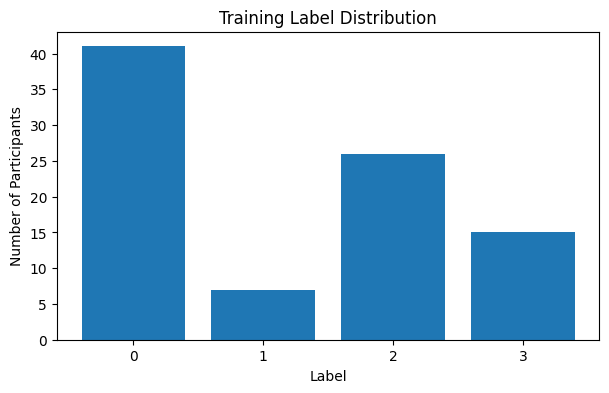

In [16]:
plt.figure(figsize=(7, 4))

plt.bar(
    label_counts.index.astype(str),
    label_counts.values
)

plt.xlabel("Label")
plt.ylabel("Number of Participants")
plt.title("Training Label Distribution")

plt.show()

In [17]:
display(train_df["Score"].describe())

,Score
count,89.000000
mean,16.719101
std,15.355624
min,0.000000
25%,0.000000
50%,16.000000
75%,32.000000
max,43.000000


In [18]:
label_score = train_df.groupby("Label")["Score"].agg(
    ["count", "min", "max", "mean", "std"]
)

display(label_score)

,count,min,max,mean,std
Label,,,,,
0,41,0,6,1.463415,2.001219
1,7,12,19,15.857143,2.672612
2,26,23,34,28.884615,4.217363
3,15,35,43,37.733333,2.433888


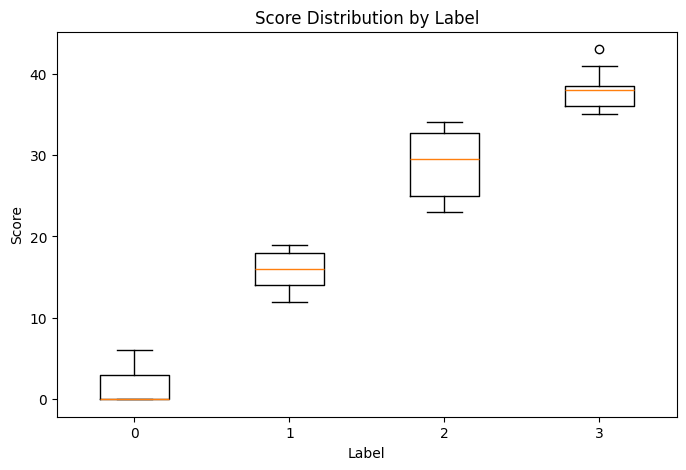

In [19]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        train_df.loc[
            train_df["Label"] == label,
            "Score"
        ].dropna()
        for label in sorted(train_df["Label"].unique())
    ],
    labels=sorted(train_df["Label"].unique())
)

plt.xlabel("Label")
plt.ylabel("Score")
plt.title("Score Distribution by Label")

plt.show()

In [20]:
print("Gender distribution:")
display(train_df["Gender"].value_counts())

Gender distribution:


,count
Gender,
Female,63
Male,26


In [21]:
print(train_df["Age"].describe())

count    89.000000
mean     29.606742
std       8.372870
min      15.000000
25%      24.000000
50%      29.000000
75%      35.000000
max      61.000000
Name: Age, dtype: float64


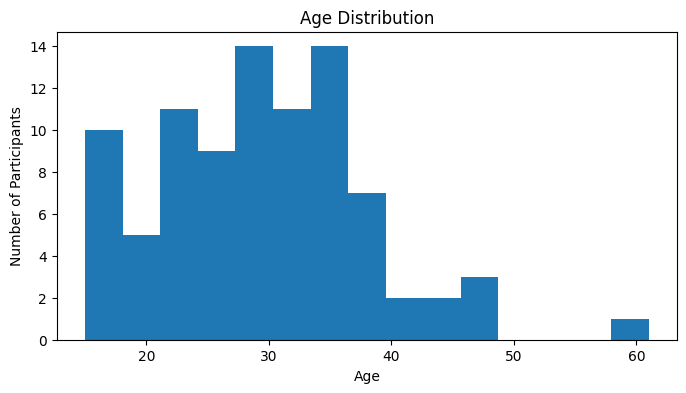

In [22]:
plt.figure(figsize=(8, 4))

plt.hist(train_df["Age"], bins=15)

plt.xlabel("Age")
plt.ylabel("Number of Participants")
plt.title("Age Distribution")

plt.show()

In [23]:
TRAIN_AUDIO_PATH = os.path.join(
    DATASET_PATH,
    "train"
)

train_df["audio_path"] = train_df["File_name"].apply(
    lambda filename: os.path.join(
        TRAIN_AUDIO_PATH,
        filename
    )
)

display(
    train_df[
        ["Participant", "File_name", "Label", "audio_path"]
    ].head()
)

,Participant,File_name,Label,audio_path
0,S026,S026.mp3,2,/content/drive/MyDrive/bio-cas-2024-depression...
1,S055,S055.mp3,3,/content/drive/MyDrive/bio-cas-2024-depression...
2,S029,S029.mp3,0,/content/drive/MyDrive/bio-cas-2024-depression...
3,S089,S089.mp3,0,/content/drive/MyDrive/bio-cas-2024-depression...
4,S005,S005.mp3,2,/content/drive/MyDrive/bio-cas-2024-depression...


In [24]:
train_df["file_exists"] = train_df["audio_path"].apply(
    os.path.isfile
)

print(
    train_df["file_exists"].value_counts()
)

file_exists
True    89
Name: count, dtype: int64


In [25]:
missing_audio = train_df[
    ~train_df["file_exists"]
]

display(missing_audio)

,Participant,File_name,Label,Score,Gender,Age,Remark,audio_path,file_exists


In [26]:
sample_row = train_df.iloc[0]

sample_audio, sample_sr = librosa.load(
    sample_row["audio_path"],
    sr=None,
    mono=True
)

print("Participant:", sample_row["Participant"])
print("File:", sample_row["File_name"])
print("Label:", sample_row["Label"])
print("Sampling rate:", sample_sr)
print("Number of samples:", len(sample_audio))
print(
    "Duration:",
    round(len(sample_audio) / sample_sr, 2),
    "seconds"
)

Participant: S026
File: S026.mp3
Label: 2
Sampling rate: 48000
Number of samples: 21109760
Duration: 439.79 seconds


display(
    Audio(
        sample_audio,
        rate=sample_sr
    )
)

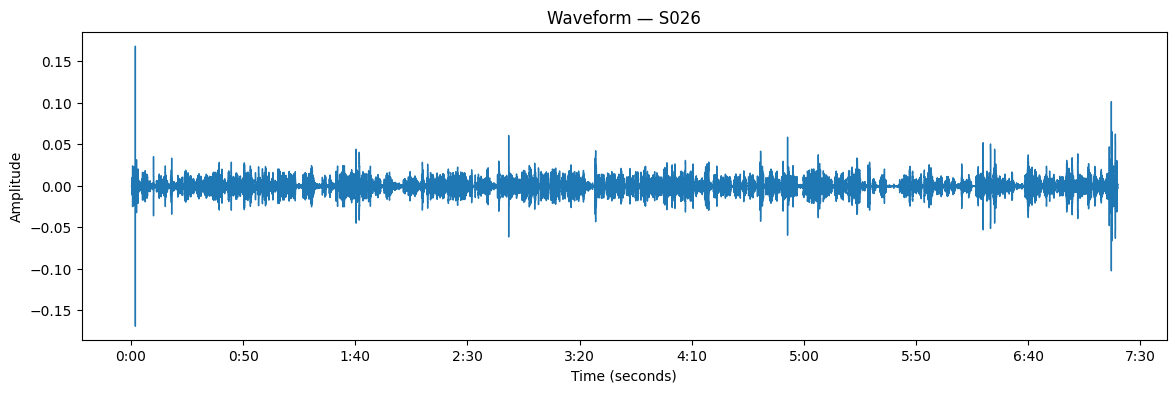

In [29]:
plt.figure(figsize=(14, 4))

librosa.display.waveshow(
    sample_audio,
    sr=sample_sr
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title(
    f"Waveform — {sample_row['Participant']}"
)

plt.show()

In [30]:
spectrogram = librosa.stft(sample_audio)

spectrogram_db = librosa.amplitude_to_db(
    np.abs(spectrogram),
    ref=np.max
)

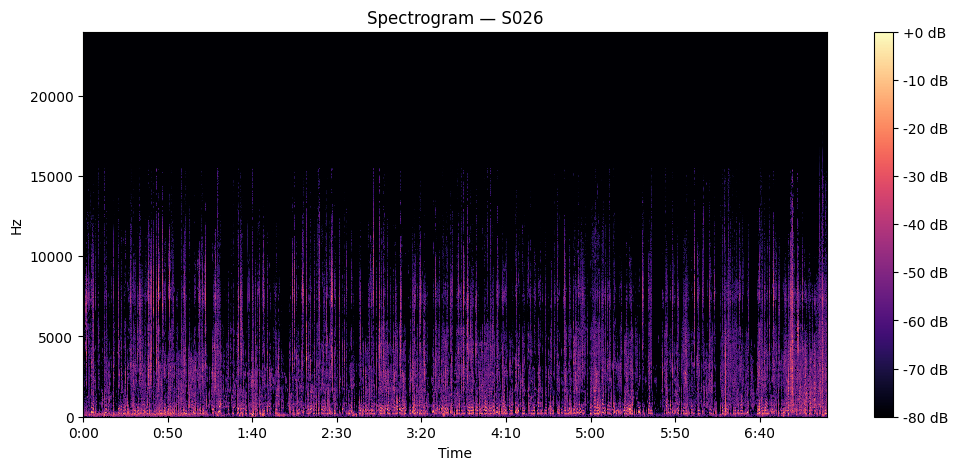

In [31]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    spectrogram_db,
    sr=sample_sr,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")

plt.title(
    f"Spectrogram — {sample_row['Participant']}"
)

plt.show()

In [32]:
durations = []

for path in train_df["audio_path"]:

    audio, sr = librosa.load(
        path,
        sr=None,
        mono=True
    )

    duration = len(audio) / sr

    durations.append(duration)

train_df["duration_sec"] = durations

In [33]:
display(
    train_df["duration_sec"].describe()
)

,duration_sec
count,89.000000
mean,368.148331
std,266.636327
min,0.017415
25%,147.328000
50%,319.189333
75%,519.594667
max,1405.979864


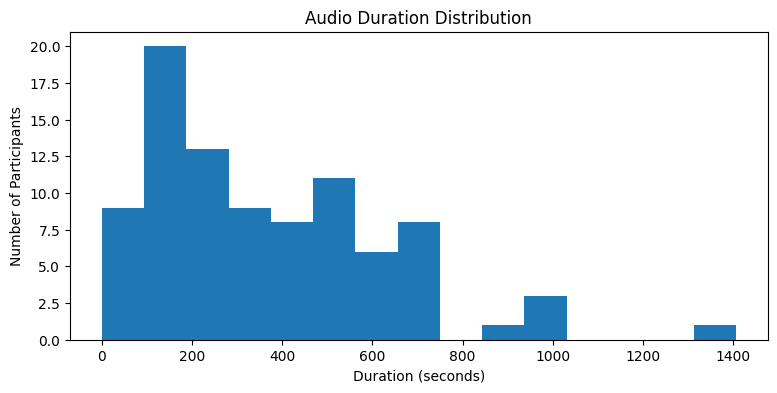

In [34]:
plt.figure(figsize=(9, 4))

plt.hist(
    train_df["duration_sec"],
    bins=15
)

plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Participants")
plt.title("Audio Duration Distribution")

plt.show()

In [35]:
train_df.groupby("Label")["Score"].agg(
    ["count", "min", "max", "mean", "std"]
)

,count,min,max,mean,std
Label,,,,,
0,41,0,6,1.463415,2.001219
1,7,12,19,15.857143,2.672612
2,26,23,34,28.884615,4.217363
3,15,35,43,37.733333,2.433888


In [36]:
print(train_df["Remark"].value_counts(dropna=False))

Remark
NaN        83
Bipolar     3
Relief      3
Name: count, dtype: int64


In [37]:
display(
    train_df[
        train_df["Remark"].notna()
    ][
        ["Participant", "Label", "Score", "Gender", "Age", "Remark"]
    ]
)

,Participant,Label,Score,Gender,Age,Remark
5,S027,0,2,Female,43,Bipolar
51,S047,2,34,Female,35,Bipolar
53,S034,2,28,Female,22,Relief
66,S050,2,34,Female,35,Bipolar
73,S035,2,23,Male,28,Relief
88,S031,2,23,Female,18,Relief


In [38]:
print(
    pd.crosstab(
        train_df["Label"],
        train_df["Remark"],
        dropna=False
    )
)

Remark  Bipolar  Relief  NaN
Label                       
0             1       0   40
1             0       0    7
2             2       3   21
3             0       0   15


In [39]:
#processed version
TARGET_SR = 16000

audio_16k = librosa.resample(
    audio,
    orig_sr=sr,
    target_sr=TARGET_SR
)

print("Original sampling rate:", sr)
print("New sampling rate:", TARGET_SR)
print("Original samples:", len(audio))
print("New samples:", len(audio_16k))
print(
    "Duration:",
    round(len(audio_16k) / TARGET_SR, 2),
    "seconds"
)

Original sampling rate: 44100
New sampling rate: 16000
Original samples: 11863680
New samples: 4304283
Duration: 269.02 seconds


In [40]:
# Short-Time Fourier Transform

stft = librosa.stft(
    audio_16k,
    n_fft=1024,
    hop_length=256
)

spectrogram = np.abs(stft)

print("STFT shape:", stft.shape)
print("Spectrogram shape:", spectrogram.shape)

STFT shape: (513, 16814)
Spectrogram shape: (513, 16814)


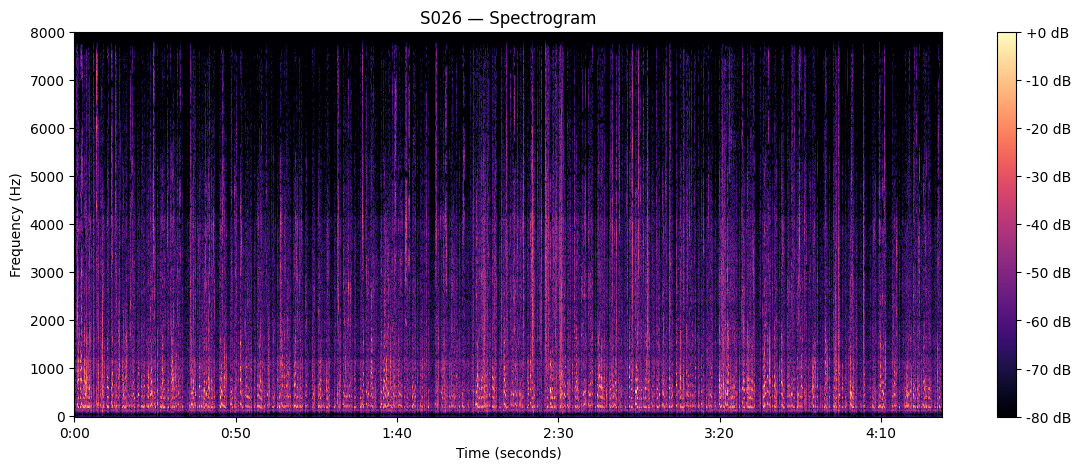

In [41]:
plt.figure(figsize=(14, 5))

librosa.display.specshow(
    librosa.amplitude_to_db(
        spectrogram,
        ref=np.max
    ),
    sr=TARGET_SR,
    hop_length=256,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("S026 — Spectrogram")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")

plt.show()

In [42]:
mel_spec = librosa.feature.melspectrogram(
    y=audio_16k,
    sr=TARGET_SR,
    n_fft=1024,
    hop_length=256,
    n_mels=64
)

mel_spec_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

print("Mel spectrogram shape:", mel_spec.shape)

Mel spectrogram shape: (64, 16814)


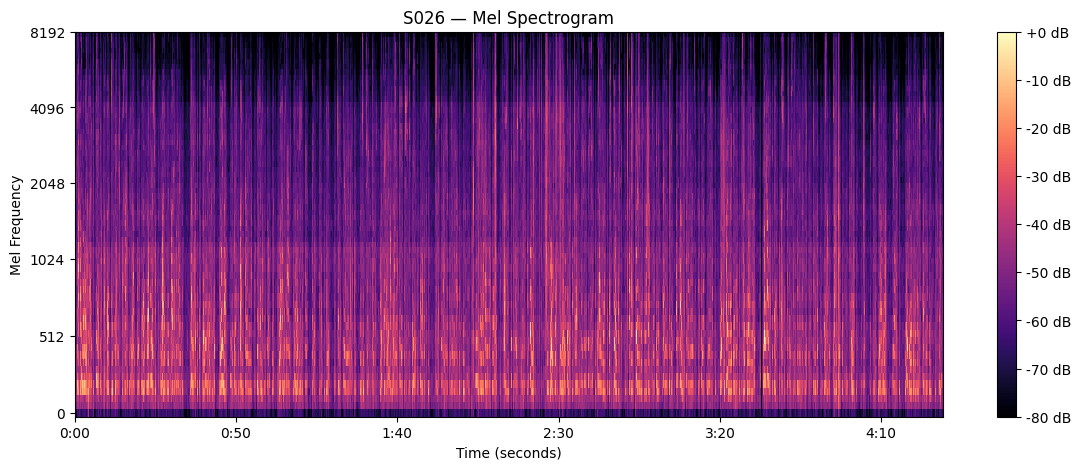

In [43]:
plt.figure(figsize=(14, 5))

librosa.display.specshow(
    mel_spec_db,
    sr=TARGET_SR,
    hop_length=256,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("S026 — Mel Spectrogram")
plt.xlabel("Time (seconds)")
plt.ylabel("Mel Frequency")

plt.show()

In [44]:
mfcc = librosa.feature.mfcc(
    y=audio_16k,
    sr=TARGET_SR,
    n_mfcc=13,
    n_fft=1024,
    hop_length=256
)

print("MFCC shape:", mfcc.shape)

MFCC shape: (13, 16814)


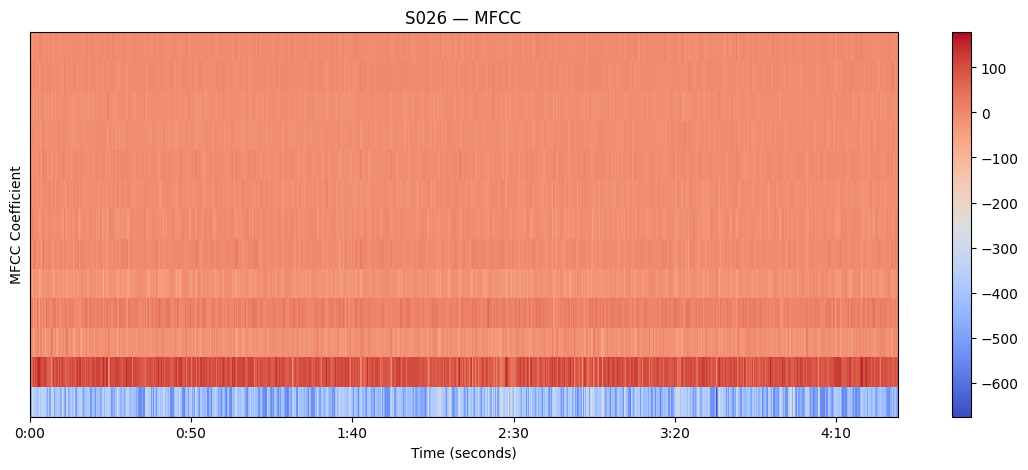

In [45]:
plt.figure(figsize=(14, 5))

librosa.display.specshow(
    mfcc,
    sr=TARGET_SR,
    hop_length=256,
    x_axis="time"
)

plt.colorbar()
plt.title("S026 — MFCC")
plt.xlabel("Time (seconds)")
plt.ylabel("MFCC Coefficient")

plt.show()

In [46]:
print("STFT shape:", stft.shape)
print("Mel spectrogram shape:", mel_spec.shape)
print("MFCC shape:", mfcc.shape)

STFT shape: (513, 16814)
Mel spectrogram shape: (64, 16814)
MFCC shape: (13, 16814)


In [47]:
def extract_mfcc_features(
    audio_path,
    sr=16000,
    n_mfcc=13,
    n_fft=1024,
    hop_length=256
):

    # Load and resample
    audio, _ = librosa.load(
        audio_path,
        sr=sr,
        mono=True
    )

    # Remove DC offset
    audio = audio - np.mean(audio)

    # Normalize amplitude
    max_amp = np.max(np.abs(audio))

    if max_amp > 0:
        audio = audio / max_amp

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop_length
    )

    # Statistics over time
    mfcc_mean = np.mean(
        mfcc,
        axis=1
    )

    mfcc_std = np.std(
        mfcc,
        axis=1
    )

    # Fixed-length representation
    features = np.concatenate(
        [mfcc_mean, mfcc_std]
    )

    return features

In [48]:
sample_features = extract_mfcc_features(
    sample_row["audio_path"]
)

print("Feature shape:", sample_features.shape)

Feature shape: (26,)


In [49]:
X_mfcc = []

for i, path in enumerate(train_df["audio_path"]):

    features = extract_mfcc_features(path)
    X_mfcc.append(features)

    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/{len(train_df)} files")

X_mfcc = np.array(X_mfcc)

print("\nFinal feature matrix:", X_mfcc.shape)

Processed 10/89 files
Processed 20/89 files
Processed 30/89 files
Processed 40/89 files
Processed 50/89 files
Processed 60/89 files
Processed 70/89 files
Processed 80/89 files

Final feature matrix: (89, 26)


In [50]:
y = train_df["Label"].to_numpy()

print("X:", X_mfcc.shape)
print("y:", y.shape)

X: (89, 26)
y: (89,)


In [51]:
FEATURE_DIR = os.path.join(
    DATASET_PATH,
    "processed_features"
)

os.makedirs(
    FEATURE_DIR,
    exist_ok=True
)

np.save(
    os.path.join(FEATURE_DIR, "X_mfcc.npy"),
    X_mfcc
)

np.save(
    os.path.join(FEATURE_DIR, "y.npy"),
    y
)

print("MFCC features saved successfully.")

MFCC features saved successfully.


In [52]:
feature_columns = [
    f"mfcc_{i+1}_mean"
    for i in range(13)
] + [
    f"mfcc_{i+1}_std"
    for i in range(13)
]

mfcc_df = pd.DataFrame(
    X_mfcc,
    columns=feature_columns
)

mfcc_df.insert(
    0,
    "Participant",
    train_df["Participant"].values
)

mfcc_df["Label"] = train_df["Label"].values

display(mfcc_df.head())

,Participant,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,...,mfcc_5_std,mfcc_6_std,mfcc_7_std,mfcc_8_std,mfcc_9_std,mfcc_10_std,mfcc_11_std,mfcc_12_std,mfcc_13_std,Label
0,S026,-408.059998,64.791702,4.614457,28.927467,-5.147283,-2.685326,-1.825226,-2.585869,0.770190,...,20.233099,19.149216,18.663908,16.894600,15.147261,14.426632,13.435078,12.850218,11.077933,2
1,S055,-443.412659,60.646404,3.735127,7.698284,-22.796457,-6.714063,-12.028667,-8.858923,-6.754483,...,18.676716,13.728598,13.719093,11.959475,11.692233,9.688877,10.371411,8.791686,8.389952,3
2,S029,-337.756836,98.257393,-14.233162,7.344659,-23.775692,1.928771,-2.385843,-9.698417,-8.479616,...,16.361135,12.473603,12.979433,10.797666,9.091736,8.059444,7.574778,8.559546,7.643039,0
3,S089,-337.286163,55.490509,-102.084839,63.285213,-25.802862,19.451666,-55.592548,21.373257,-17.941099,...,27.674234,20.090330,32.231644,17.004166,23.200670,16.053244,29.664104,15.175997,17.686462,0
4,S005,-482.222046,90.404793,-7.710196,4.281353,-23.792429,-6.135524,-9.177065,-10.343594,-7.641799,...,15.975082,10.264827,11.693001,11.708705,8.863676,8.275783,7.637195,7.642966,7.287965,2
